=========================================================
### TFM - EDA 01
### KPIs Y ANÁLISIS EXPLORATORIO INICIAL
=========================================================

In [150]:
# =========================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
pd.set_option('display.max_columns', None)


In [151]:
# =========================================================
# 2. CARGA DEL DATASET
# =========================================================

df = pd.read_csv('G:\Mi unidad\TFM UNIR\Python\Datos\dataset_consolidado.csv', sep=",")

print('Dimensiones del dataset:')
print(df.shape)

print('\nPrimeras filas:')
print(df.head())

Dimensiones del dataset:
(117757, 19)

Primeras filas:
    AÑO  TRIMESTRE   TIPO SECRETARÍA  CÓDIGO FONDO  \
0  2020          1  GASTO    BOLIVAR  1.136830e+11   
1  2020          1  GASTO    BOLIVAR  1.136830e+11   
2  2020          1  GASTO    BOLIVAR  1.136830e+11   
3  2020          1  GASTO    BOLIVAR  1.136830e+11   
4  2020          1  GASTO    BOLIVAR  1.136830e+11   

                           FONDO         NOMBRE ESTABLECIMIENTO  \
0  CENTRO EDUCATIVO DE CHIRICOCO  CENTRO EDUCATIVO DE CHIRICOCO   
1  CENTRO EDUCATIVO DE CHIRICOCO  CENTRO EDUCATIVO DE CHIRICOCO   
2  CENTRO EDUCATIVO DE CHIRICOCO  CENTRO EDUCATIVO DE CHIRICOCO   
3  CENTRO EDUCATIVO DE CHIRICOCO  CENTRO EDUCATIVO DE CHIRICOCO   
4  CENTRO EDUCATIVO DE CHIRICOCO  CENTRO EDUCATIVO DE CHIRICOCO   

   CÓDIGO ESTABLECIMIENTO  CÓDIGO FUENTE DE INGRESO FUENTE INGRESO  \
0            113683000727                         2      Gratuidad   
1            113683000727                         2      Gratuidad   
2      

In [152]:
# =========================================================
# 3. INFORMACIÓN GENERAL
# =========================================================
print('\n================ INFO GENERAL ================')
print(df.info())


================ INFO GENERAL ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117757 entries, 0 to 117756
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AÑO                       117757 non-null  int64  
 1   TRIMESTRE                 117757 non-null  int64  
 2   TIPO                      117757 non-null  object 
 3   SECRETARÍA                103487 non-null  object 
 4   CÓDIGO FONDO              103487 non-null  float64
 5   FONDO                     103487 non-null  object 
 6   NOMBRE ESTABLECIMIENTO    103487 non-null  object 
 7   CÓDIGO ESTABLECIMIENTO    117757 non-null  int64  
 8   CÓDIGO FUENTE DE INGRESO  117757 non-null  int64  
 9   FUENTE INGRESO            117757 non-null  object 
 10  CÓDIGO ITEM DETALLE       100074 non-null  float64
 11  ITEM DETALLE              100074 non-null  object 
 12  PRESUPUESTO INICIAL       117757 non-null  int64  
 

In [153]:
# Identificar la cantidad de registros que contienen Ingresos en el dataset para poder filtar esa variable
df["TIPO"].value_counts()

TIPO
GASTO      100074
INGRESO     17683
Name: count, dtype: int64

In [154]:
# =========================================================
# 4. FILTRO COMPONENTE GASTO
# =========================================================
# El análisis se orienta a la ejecución presupuestal,
# por lo cual se conservan únicamente los registros
# asociados al componente de gasto.
# =========================================================

print('\n================ FILTRO GASTOS ================')

df = df[
    df['TIPO'] == 'GASTO'
].copy()

print('\nDimensión después del filtro:')
print(df.shape)

print('\nDistribución TIPO:')

print(
    df['TIPO']
    .value_counts(dropna=False)
)


================ FILTRO GASTOS ================

Dimensión después del filtro:
(100074, 19)

Distribución TIPO:
TIPO
GASTO    100074
Name: count, dtype: int64


In [155]:
# =========================================================
# 5. LIMPIEZA Y RENOMBRE DE COLUMNAS
# =========================================================

# ---------------------------------------------------------
# Eliminar columnas que no aportan al análisis
# ---------------------------------------------------------

columnas_eliminar = [
    'SECRETARÍA',
    'CÓDIGO FONDO',
    'FONDO',
    'origen_archivo'
]

df = df.drop(
    columns=columnas_eliminar,
    errors='ignore'
)

print('\n================ COLUMNAS ELIMINADAS ================')

print(columnas_eliminar)

# ---------------------------------------------------------
# Renombrar columnas
# ---------------------------------------------------------

df = df.rename(columns={
    'AÑO': 'ANNO',
    'CÓDIGO ESTABLECIMIENTO': 'DANE',
    'CÓDIGO FUENTE DE INGRESO': 'COD_FUENTE_INGRESO',
    'CÓDIGO ITEM DETALLE': 'COD_ITEM_DETALLE',
    'PRESUPUESTO INICIAL': 'PRESP_INICIAL',
    'PRESUPUESTO DEFINITIVO': 'PRESP_DEFINITIVO',
    'MONTO RECAUDADO': 'RECAUDO'

})

print('\n================ COLUMNAS RENOMBRADAS ================')

print(df.columns)


================ COLUMNAS ELIMINADAS ================
['SECRETARÍA', 'CÓDIGO FONDO', 'FONDO', 'origen_archivo']

================ COLUMNAS RENOMBRADAS ================
Index(['ANNO', 'TRIMESTRE', 'TIPO', 'NOMBRE ESTABLECIMIENTO', 'DANE',
       'COD_FUENTE_INGRESO', 'FUENTE INGRESO', 'COD_ITEM_DETALLE',
       'ITEM DETALLE', 'PRESP_INICIAL', 'PRESP_DEFINITIVO', 'COMPROMISOS',
       'OBLIGACIONES', 'PAGOS', 'RECAUDO'],
      dtype='object')


In [156]:
# =========================================================
# 6. VALIDACIÓN DE NULOS
# =========================================================

print('\n================ VALORES NULOS ================')

nulos = pd.DataFrame({
    'NULOS': df.isnull().sum(),
    'PORCENTAJE': (
        df.isnull().mean() * 100
    ).round(2)
})

nulos = nulos.sort_values(
    by='PORCENTAJE',
    ascending=False
)

print(nulos)


================ VALORES NULOS ================
                        NULOS  PORCENTAJE
NOMBRE ESTABLECIMIENTO  13452       13.44
ANNO                        0        0.00
TRIMESTRE                   0        0.00
TIPO                        0        0.00
DANE                        0        0.00
COD_FUENTE_INGRESO          0        0.00
FUENTE INGRESO              0        0.00
COD_ITEM_DETALLE            0        0.00
ITEM DETALLE                0        0.00
PRESP_INICIAL               0        0.00
PRESP_DEFINITIVO            0        0.00
COMPROMISOS                 0        0.00
OBLIGACIONES                0        0.00
PAGOS                       0        0.00
RECAUDO                     0        0.00


In [157]:
# =========================================================
# 7. VARIABLES FINANCIERAS
# =========================================================

variables_financieras = [
    'PRESP_INICIAL',
    'PRESP_DEFINITIVO',
    'COMPROMISOS',
    'OBLIGACIONES',
    'PAGOS',
]

In [158]:
# =========================================================
# 8. TRATAMIENTO DE NULOS
# =========================================================

# ---------------------------------------------------------
# Variables financieras
# ---------------------------------------------------------
# Los nulos financieros se interpretan como:
# ausencia de ejecución / recaudo / obligación
# =========================================================

for col in variables_financieras:

    if col in df.columns:

        df[col] = df[col].fillna(0)

# ---------------------------------------------------------
# Variables categóricas
# ---------------------------------------------------------

variables_categoricas = df.select_dtypes(
    include='object'
).columns

for col in variables_categoricas:

    df[col] = df[col].fillna('NO_REPORTADO')



In [159]:
# =========================================================
# 7. VALIDACIÓN POSTERIOR A NULOS
# =========================================================

print('\n================ NULOS DESPUÉS DEL TRATAMIENTO ================')

print(df.isnull().sum().sum())


================ NULOS DESPUÉS DEL TRATAMIENTO ================
0


In [160]:
# =========================================================
# 8. ESTANDARIZACIÓN DE VARIABLES TEXTUALES
# =========================================================

print('\n================ ESTANDARIZACIÓN TEXTUAL ================')

# =========================================================
# FUNCIÓN PARA CORREGIR ENCODING
# =========================================================

def corregir_texto(texto):

    try:

        return (
            texto
            .encode('latin1')
            .decode('utf-8')
        )

    except:

        return texto

# =========================================================
# COLUMNAS TEXTUALES A LIMPIAR
# =========================================================

columnas_textuales = [
    'NOMBRE ESTABLECIMIENTO',
    'ITEM DETALLE',
    'FUENTE INGRESO'
]

# =========================================================
# CORRECCIÓN TEXTUAL
# =========================================================

for col in columnas_textuales:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .apply(corregir_texto)
            .str.upper()
            .str.strip()
            .replace(
                r'^\s*$',
                'NO_REPORTADO',
                regex=True
            )
        )

print('\n================ CORRECCIÓN TEXTUAL FINALIZADA ================')

# =========================================================
# ESTANDARIZACIÓN DE NOMBRES INSTITUCIONALES
# =========================================================

# ---------------------------------------------------------
# Obtener nombre más frecuente por DANE
# ---------------------------------------------------------

nombre_estandar = (
    df[
        df['NOMBRE ESTABLECIMIENTO']
        !=
        'NO_REPORTADO'
    ]
    .groupby('DANE')['NOMBRE ESTABLECIMIENTO']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# ---------------------------------------------------------
# Diccionario de nombres
# ---------------------------------------------------------

diccionario_nombres = dict(
    zip(
        nombre_estandar['DANE'],
        nombre_estandar['NOMBRE ESTABLECIMIENTO']
    )

)

# ---------------------------------------------------------
# Reemplazar nombres inconsistentes
# ---------------------------------------------------------

df['NOMBRE ESTABLECIMIENTO'] = (
    df['DANE']
    .map(diccionario_nombres)
)

# =========================================================
# CORRECCIÓN MANUAL DE ESTABLECIMIENTOS
# =========================================================

df.loc[

    df['DANE'] == 113894000065,
    'NOMBRE ESTABLECIMIENTO'
] = 'INSTITUCIÓN EDUCATIVA TÉCNICA EN INFORMATICA ANIBAL NOGUERA MENDOZA'

# ===================================================================
# CORRECCIÓN MANUAL DANE IET INDUSTRIAL DON BOSCO ANTES DEL AÑO 2024
# ===================================================================

df['DANE'] = df['DANE'].replace(
    113052000415,
    113052800153
)

df.loc[
    (
        df['DANE'] == 113052800153
    ) &
    (
        df['NOMBRE ESTABLECIMIENTO']
        == 'INSTITUCIÓN EDUCATIVA TÉCNICA INDUSTRIAL DON BOSCO MEGACOLEGIO'
    ),
    'NOMBRE ESTABLECIMIENTO'
] = 'INSTITUCIÓN EDUCATIVA TÉCNICA INDUSTRIAL DON BOSCO'

# =========================================================
# VALIDACIÓN FINAL
# =========================================================

print('\n================ VALIDACIÓN NOMBRES ================')

validacion = (

    df.groupby('DANE')['NOMBRE ESTABLECIMIENTO']
    .nunique()
)

problemas = validacion[validacion > 1]

print(f'DANE con múltiples nombres: {problemas.shape[0]}')


================ ESTANDARIZACIÓN TEXTUAL ================

================ CORRECCIÓN TEXTUAL FINALIZADA ================

================ VALIDACIÓN NOMBRES ================
DANE con múltiples nombres: 0


In [161]:
# =========================================================
# 9. VALIDACIÓN DE DUPLICADOS
# =========================================================

print('\n================ DUPLICADOS ================')

duplicados = df[df.duplicated()]

print(f'Registros duplicados exactos: {duplicados.shape[0]}')


================ DUPLICADOS ================
Registros duplicados exactos: 348


In [162]:
# =============================================================
# Verificar duplicados y almacenar en Hoja Excel para analizar
# ==============================================================
duplicados = df[df.duplicated()]
duplicados.to_excel("registros_duplicados.xlsx", index=False)


In [163]:
# =========================================================
# 10. ELIMINACIÓN DE DUPLICADOS EXACTOS
# =========================================================

df = df.drop_duplicates()

print('\n================ DIMENSIONES SIN DUPLICADOS ================')

print(df.shape)


================ DIMENSIONES SIN DUPLICADOS ================
(99726, 15)


In [164]:
# =========================================================
# 11. VALIDACIÓN DE CARDINALIDAD
# =========================================================

print('\n================ CARDINALIDAD ================')

cardinalidad = pd.DataFrame({
    'VARIABLE': df.columns,
    'UNIQUE_VALUES': [
        df[col].nunique()
        for col in df.columns
    ]
})

cardinalidad = cardinalidad.sort_values(
    by='UNIQUE_VALUES',
    ascending=False
)

print(cardinalidad)


================ CARDINALIDAD ================
                  VARIABLE  UNIQUE_VALUES
10        PRESP_DEFINITIVO          17304
13                   PAGOS          16265
12            OBLIGACIONES          15732
11             COMPROMISOS          15642
9            PRESP_INICIAL           5020
3   NOMBRE ESTABLECIMIENTO            226
4                     DANE            226
8             ITEM DETALLE             73
7         COD_ITEM_DETALLE             61
6           FUENTE INGRESO             55
5       COD_FUENTE_INGRESO             38
0                     ANNO              6
1                TRIMESTRE              4
2                     TIPO              1
14                 RECAUDO              1


In [165]:
# =========================================================
# 12 VALIDACIÓN DE VALORES NEGATIVOS
# =========================================================

print('\n================ VALORES NEGATIVOS ================')

for col in variables_financieras:

    negativos = (
        df[col] < 0
    ).sum()

    print(f'{col}: {negativos}')



================ VALORES NEGATIVOS ================
PRESP_INICIAL: 0
PRESP_DEFINITIVO: 0
COMPROMISOS: 0
OBLIGACIONES: 0
PAGOS: 1


In [166]:
# =========================================================
# 13. KPIs PRESUPUESTALES
# =========================================================
# Los indicadores se expresan en porcentaje (%)
# =========================================================

# ---------------------------------------------------------
# Índice de ejecución
# ---------------------------------------------------------

df['IND_EJECUCION'] = np.where(
    df['PRESP_DEFINITIVO'] > 0,
    (
        df['PAGOS']
        /
        df['PRESP_DEFINITIVO']
    ) * 100,
    np.nan
).round(2)

# ---------------------------------------------------------
# Índice de obligaciones
# ---------------------------------------------------------
"""
df['IND_OBLIGACION'] = np.where(
    df['PRESP_DEFINITIVO'] > 0,
    (
        df['OBLIGACIONES']
        /
        df['PRESP_DEFINITIVO']
    ) * 100,
    np.nan
).round(2)
"""

# ---------------------------------------------------------
# Índice de compromiso
# ---------------------------------------------------------

df['IND_COMPROMISO'] = np.where(
    df['PRESP_DEFINITIVO'] > 0,
    (
        df['COMPROMISOS']
        /
        df['PRESP_DEFINITIVO']
    ) * 100,
    np.nan
).round(2)



In [167]:
# =========================================================
# 14. LIMPIEZA KPIs
# =========================================================

kpis = [
    'IND_EJECUCION',
    'IND_COMPROMISO'
]

# ---------------------------------------------------------
# Reemplazar infinitos
# ---------------------------------------------------------

df[kpis] = (
    df[kpis]
    .replace([np.inf, -np.inf], np.nan)
)

# ---------------------------------------------------------
# Convertir a numérico
# ---------------------------------------------------------

for col in kpis:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )


In [168]:
# =========================================================
# 15. ORDENAMIENTO TEMPORAL
# =========================================================

df = df.sort_values(

    ['DANE', 'ANNO', 'TRIMESTRE']

)

In [169]:
# =========================================================
# 16. VARIACIÓN DE EJECUCIÓN
# =========================================================
# Cambio acumulado entre trimestres
# =========================================================

df['VAR_EJECUCION'] = (
    df.groupby(
        ['DANE', 'ANNO']
    )['IND_EJECUCION']
    .diff()
    .astype(float)
    .round(2)
)


In [170]:
# =========================================================
# 17. CREACIÓN DATASET T4
# =========================================================
# Dataset principal para análisis inferencial
# =========================================================

df_t4 = df[

    df['TRIMESTRE'] == 4

].copy()

print('\n================ DATASET T4 ================')

print(df_t4.shape)



================ DATASET T4 ================
(25488, 18)


In [171]:
# =========================================================
# 19. ESTADÍSTICA DESCRIPTIVA
# =========================================================

print('\n================ ESTADÍSTICA DESCRIPTIVA ================')

estadisticas = (
    df_t4[
        variables_financieras + kpis
    ]
    .describe()
    .T
)

# ---------------------------------------------------------
# Asimetría
# ---------------------------------------------------------

estadisticas['ASIMETRIA'] = (

    df_t4[
        variables_financieras + kpis
    ]
    .skew()

)

# ---------------------------------------------------------
# Curtosis
# ---------------------------------------------------------

estadisticas['CURTOSIS'] = (

    df_t4[
        variables_financieras + kpis
    ]
    .kurtosis()

)

print(estadisticas)



================ ESTADÍSTICA DESCRIPTIVA ================
                    count          mean           std  min     25%        50%  \
PRESP_INICIAL     25488.0  4.512115e+06  1.115523e+07  0.0   0.000       0.00   
PRESP_DEFINITIVO  25488.0  6.091901e+06  1.426251e+07  0.0   0.000  300000.00   
COMPROMISOS       25488.0  5.471566e+06  1.355439e+07  0.0   0.000       0.00   
OBLIGACIONES      25488.0  5.310725e+06  1.331597e+07  0.0   0.000       0.00   
PAGOS             25488.0  5.517889e+06  1.345952e+07  0.0   0.000       0.00   
IND_EJECUCION     14355.0  7.622407e+01  4.210246e+01  0.0  64.540      99.98   
IND_COMPROMISO    14355.0  7.583351e+01  4.211713e+01  0.0  63.115     100.00   

                         75%           max  ASIMETRIA   CURTOSIS  
PRESP_INICIAL     3700000.00  2.528169e+08   5.198959  43.702110  
PRESP_DEFINITIVO  5250000.00  3.300000e+08   4.844207  38.136756  
COMPROMISOS       4359836.25  2.800000e+08   4.882297  35.928787  
OBLIGACIONES      407411

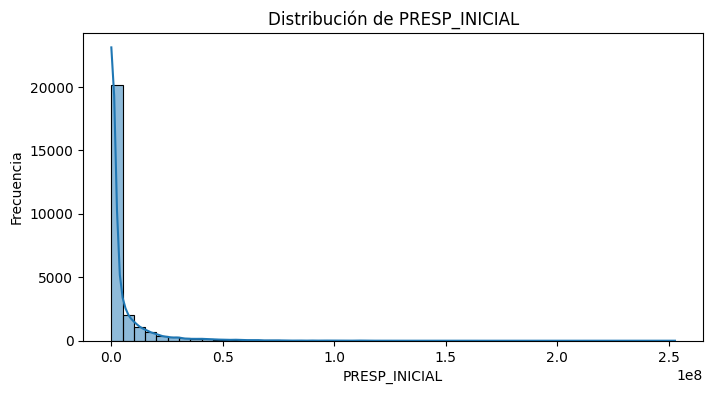

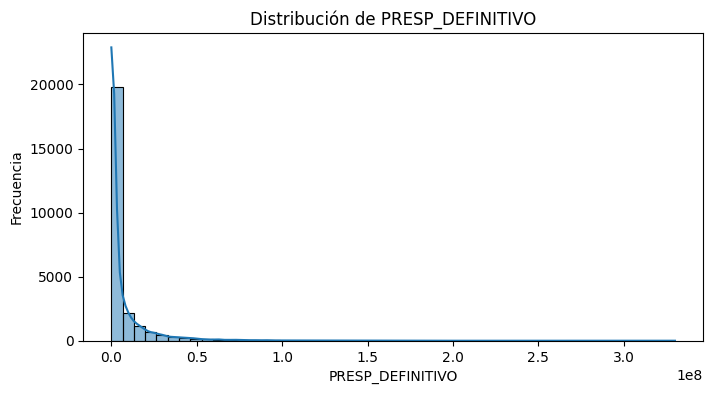

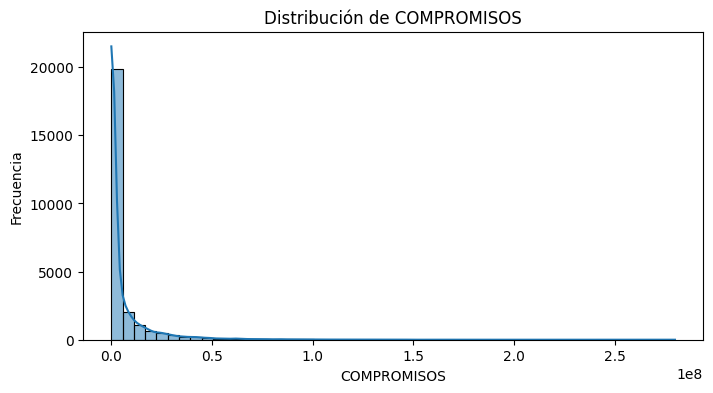

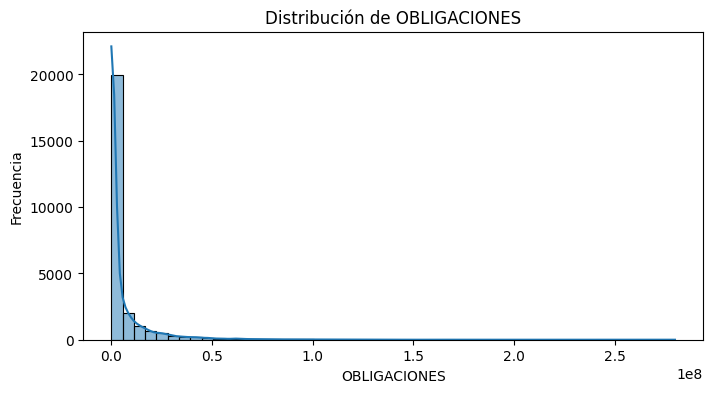

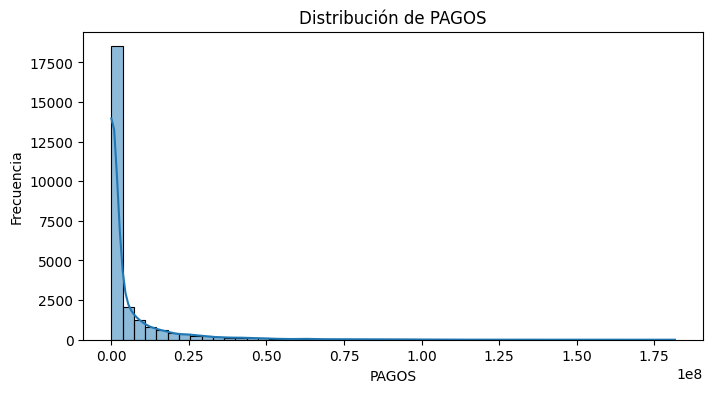

In [172]:
# =========================================================
# 20. HISTOGRAMAS
# =========================================================

for col in variables_financieras:

    plt.figure(figsize=(8,4))
    sns.histplot(
        df_t4[col],
        bins=50,
        kde=True
    )

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


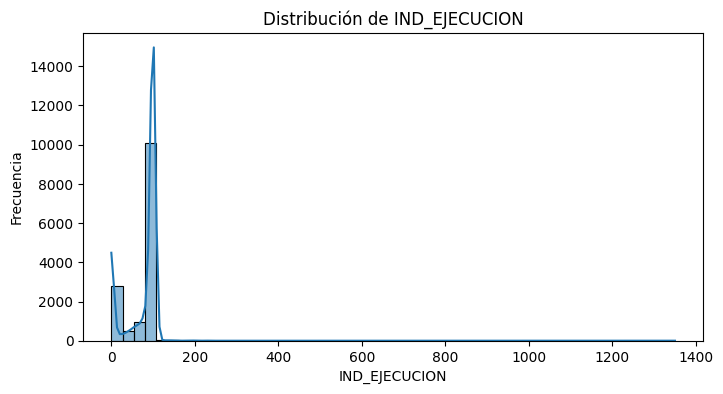

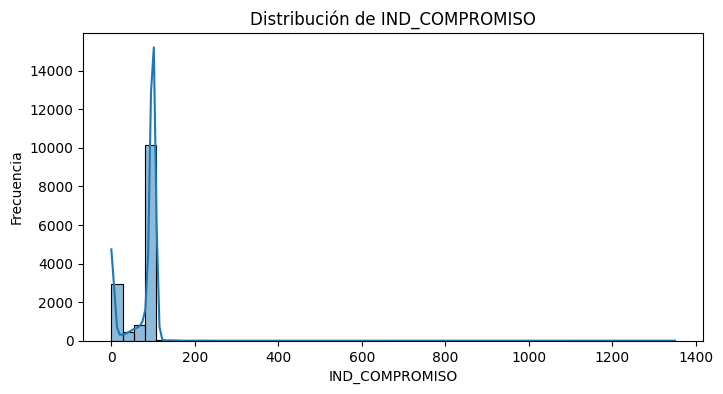

In [173]:
# =========================================================
# 21. HISTOGRAMAS KPI
# =========================================================

for col in kpis:
    plt.figure(figsize=(8,4))
    sns.histplot(
        df_t4[col],
        bins=50,
        kde=True

    )

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


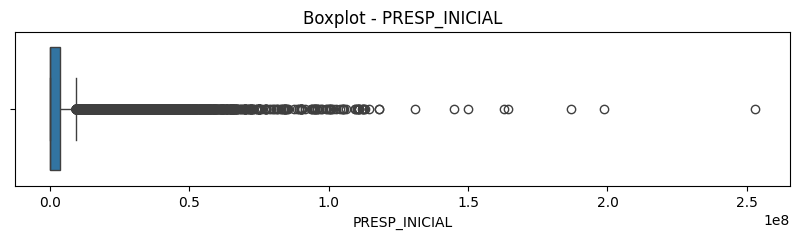

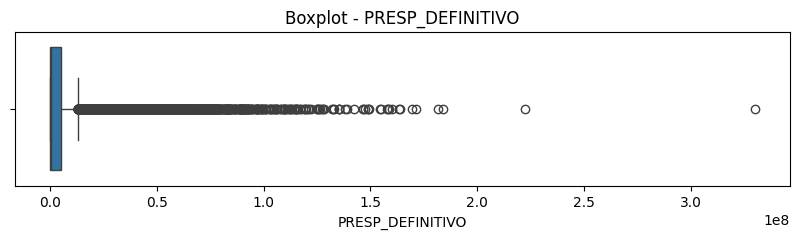

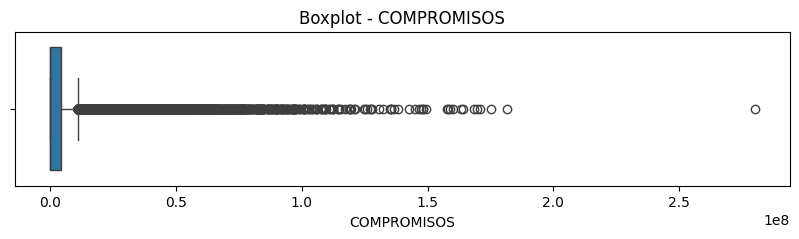

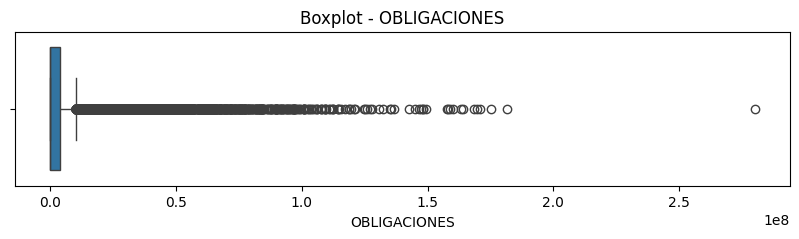

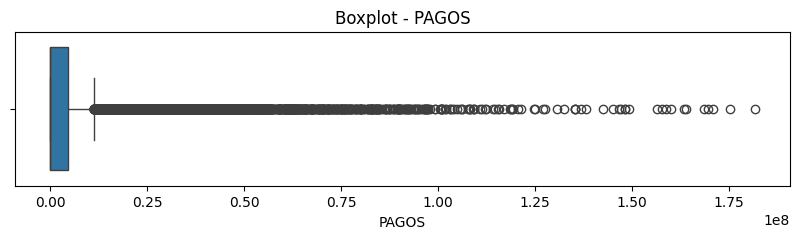

In [174]:
# =========================================================
# 22. BOXPLOTS
# =========================================================

for col in variables_financieras:
    plt.figure(figsize=(10,2))
    sns.boxplot(
        x=df_t4[col]
    )

    plt.title(f'Boxplot - {col}')
    plt.show()

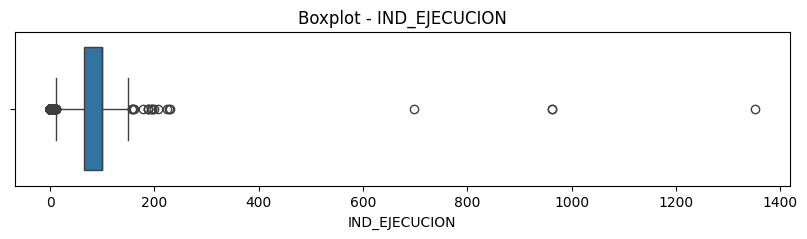

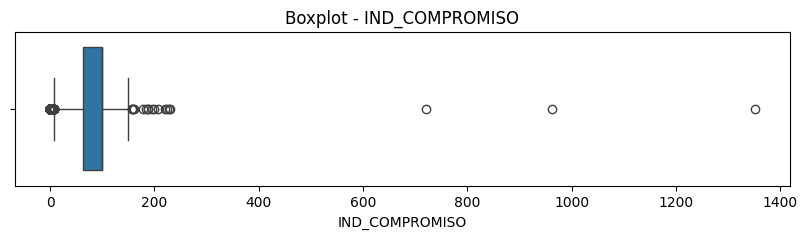

In [175]:
# =========================================================
# 23. BOXPLOTS KPI
# =========================================================

for col in kpis:
    plt.figure(figsize=(10,2))
    sns.boxplot(
        x=df_t4[col]
    )
    plt.title(f'Boxplot - {col}')
    plt.show()

In [176]:
# =========================================================
# 24. TRANSFORMACIÓN LOGARÍTMICA
# =========================================================
# Necesaria por alta asimetría
# =========================================================

for col in variables_financieras:
    df_t4[f'LOG_{col}'] = np.log1p(
        df_t4[col].clip(lower=0)

    )

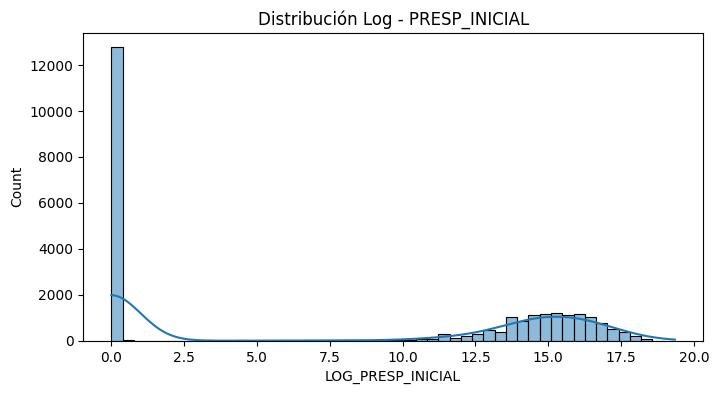

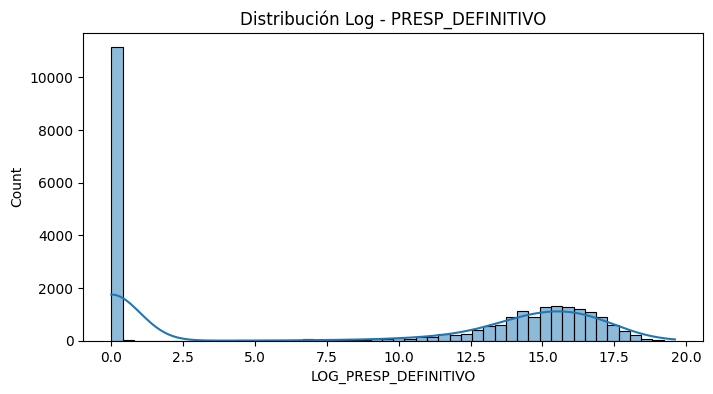

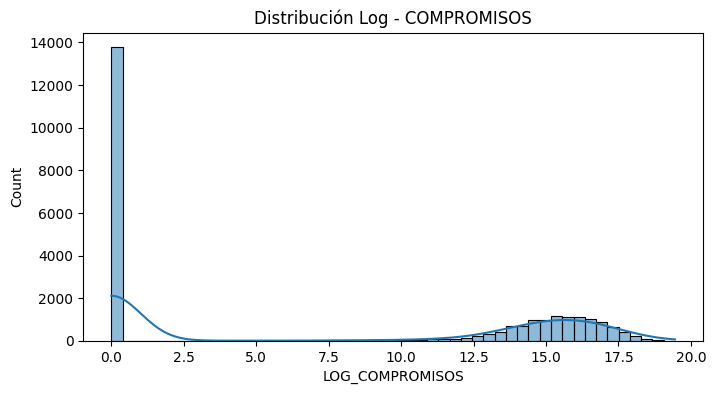

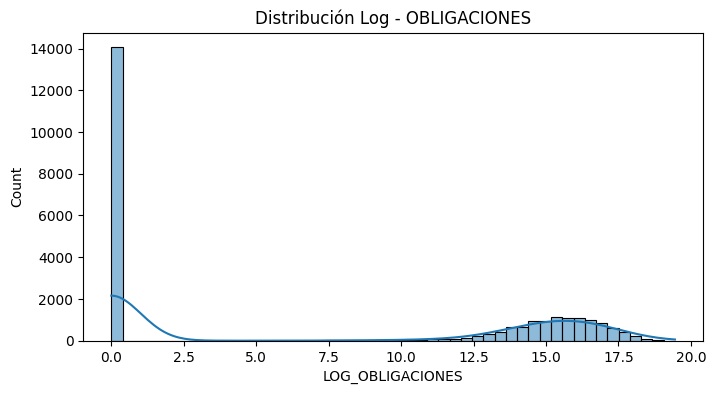

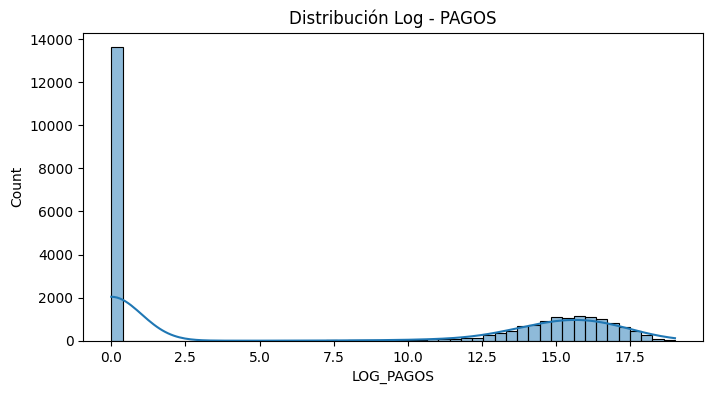

In [177]:
# =========================================================
# 25. HISTOGRAMAS LOGARÍTMICOS
# =========================================================

for col in variables_financieras:

    plt.figure(figsize=(8,4))
    sns.histplot(
        df_t4[f'LOG_{col}'],
        bins=50,
        kde=True
    )

    plt.title(f'Distribución Log - {col}')
    plt.show()


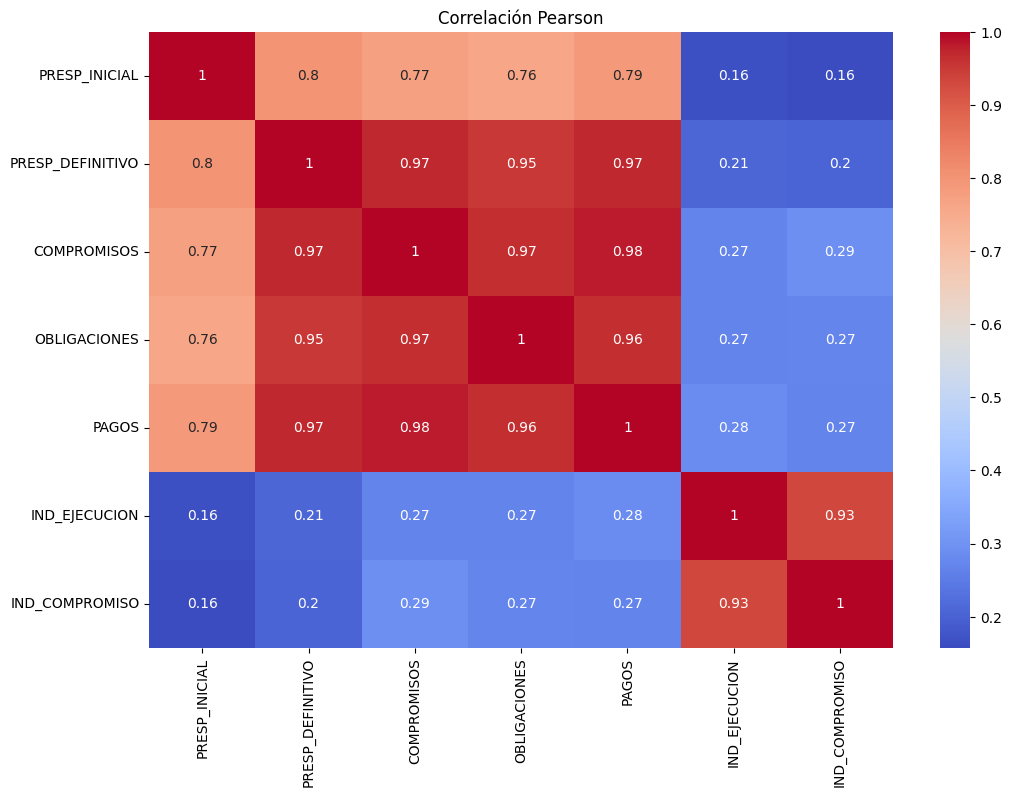

In [178]:
# =========================================================
# 26. CORRELACIONES PEARSON
# =========================================================

corr_pearson = (
    df_t4[
        variables_financieras + kpis
    ]
    .corr(method='pearson')

)

plt.figure(figsize=(12,8))
sns.heatmap(

    corr_pearson,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación Pearson')

plt.show()



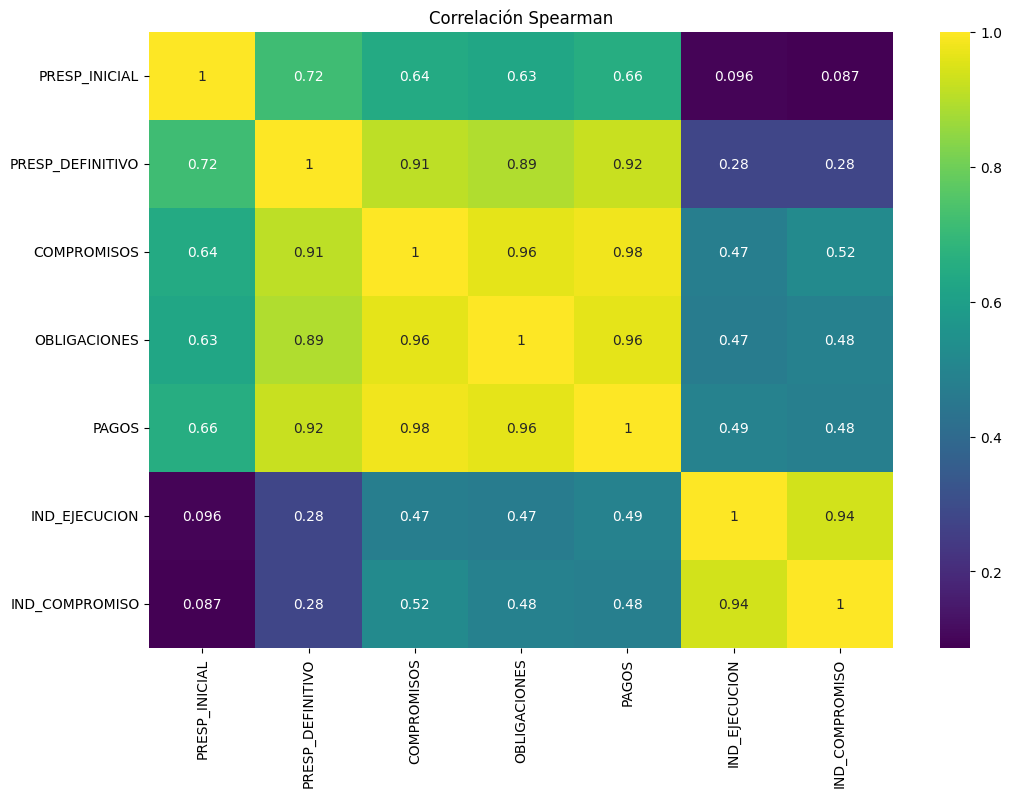

In [179]:
# =========================================================
# 27. CORRELACIONES SPEARMAN
# =========================================================

corr_spearman = (

    df_t4[
        variables_financieras + kpis
    ]
    .corr(method='spearman')

)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='viridis'

)

plt.title('Correlación Spearman')
plt.show()


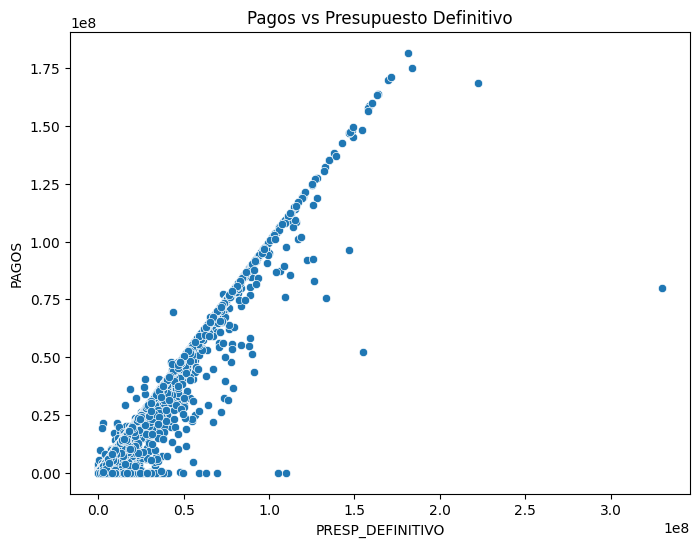

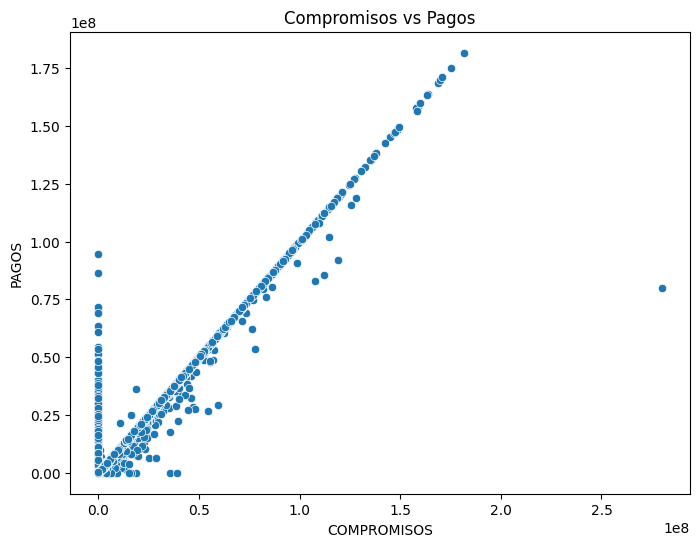

In [180]:
# =========================================================
# 28. SCATTERPLOTS
# =========================================================

# ---------------------------------------------------------
# Pagos vs presupuesto
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(

    data=df_t4,
    x='PRESP_DEFINITIVO',
    y='PAGOS'

)

plt.title('Pagos vs Presupuesto Definitivo')
plt.show()

# ---------------------------------------------------------
# Compromisos vs pagos
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(

    data=df_t4,
    x='COMPROMISOS',
    y='PAGOS'

)

plt.title('Compromisos vs Pagos')
plt.show()


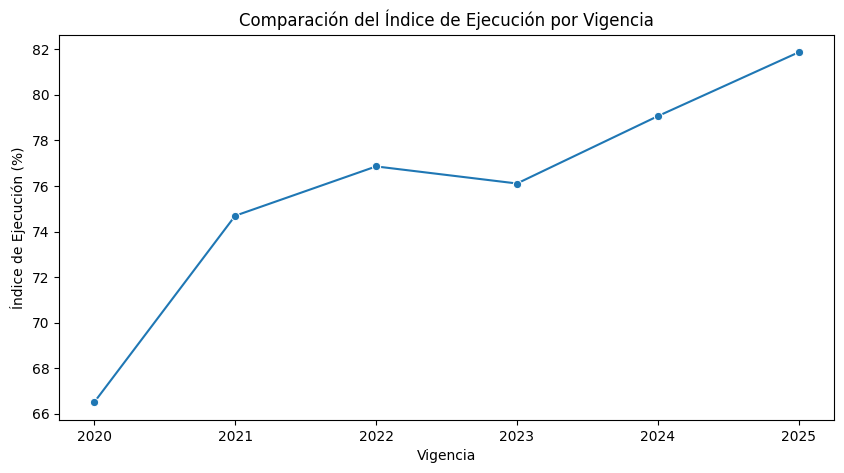

In [181]:
# =========================================================
# 28.1 EVOLUCIÓN TRIMESTRAL
# =========================================================

ejecucion_anual = (

    df_t4
    .groupby('ANNO')['IND_EJECUCION']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=ejecucion_anual,
    x='ANNO',
    y='IND_EJECUCION',
    marker='o'
)

plt.title('Comparación del Índice de Ejecución por Vigencia')
plt.ylabel('Índice de Ejecución (%)')
plt.xlabel('Vigencia')

plt.show()


   ANNO  IND_EJECUCION
0  2020      66.506062
1  2021      74.692852
2  2022      76.859188
3  2023      76.109022
4  2024      79.067679
5  2025      81.872855


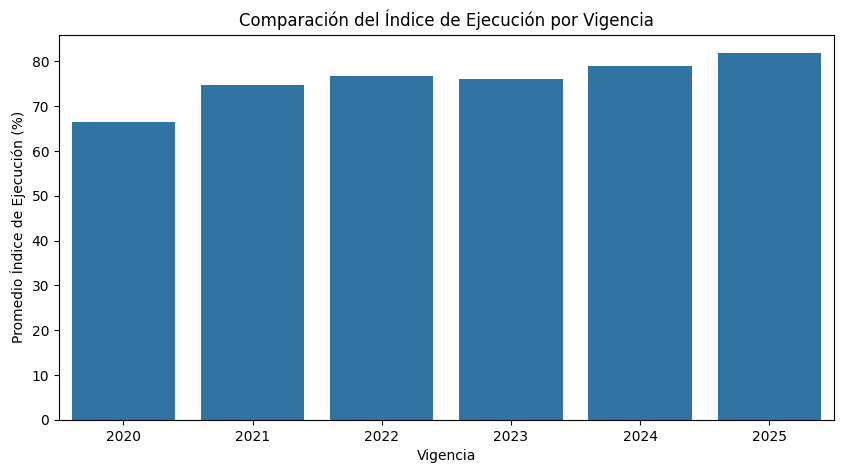

In [182]:
# =====================================================
# 29. COMPARACIÓN DE EJECUCIÓN POR VIGENCIA
# =====================================================

ejecucion_anual = (

    df_t4
    .groupby('ANNO')['IND_EJECUCION']
    .mean()
    .reset_index()

)

print(ejecucion_anual)

# =====================================================
# GRÁFICA
# =====================================================

plt.figure(figsize=(10,5))
sns.barplot(
    data=ejecucion_anual,
    x='ANNO',
    y='IND_EJECUCION'

)

plt.title(
    'Comparación del Índice de Ejecución por Vigencia'
)

plt.xlabel('Vigencia')
plt.ylabel('Promedio Índice de Ejecución (%)')
plt.show()

In [183]:
# =========================================================
# 30. ALERTAS PRESUPUESTALES ESTADÍSTICAS
# =========================================================
# Las alertas se construyen usando:
# - Percentiles
# - Método IQR
# Esto evita umbrales arbitrarios.
# =========================================================

print('\n================ ALERTAS ESTADÍSTICAS ================')

# =========================================================
# PERCENTILES
# =========================================================

p25 = df_t4['IND_EJECUCION'].quantile(0.25)
p75 = df_t4['IND_EJECUCION'].quantile(0.75)
p95 = df_t4['IND_EJECUCION'].quantile(0.95)

print(f'Percentil 25: {p25:.2f}')
print(f'Percentil 75: {p75:.2f}')
print(f'Percentil 95: {p95:.2f}')

# =========================================================
# ALERTA BAJA EJECUCIÓN
# =========================================================
# Instituciones por debajo del comportamiento típico
# =========================================================

alerta_baja = df_t4[
    df_t4['IND_EJECUCION'] < p25
]

print('\n================ ALERTA BAJA EJECUCIÓN ================')

print(alerta_baja.shape)

# =========================================================
# ALERTA ALTA EJECUCIÓN
# =========================================================

alerta_alta = df_t4[
    df_t4['IND_EJECUCION'] > p95

]

print('\n================ ALERTA ALTA EJECUCIÓN ================')
print(alerta_alta.shape)

# =========================================================
# MÉTODO IQR
# =========================================================

q1 = df_t4['IND_EJECUCION'].quantile(0.25)
q3 = df_t4['IND_EJECUCION'].quantile(0.75)
iqr = q3 - q1

# ---------------------------------------------------------
# Límites estadísticos
# ---------------------------------------------------------

limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)

print('\n================ LÍMITES IQR ================')

print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Límite inferior: {limite_inferior:.2f}')
print(f'Límite superior: {limite_superior:.2f}')



================ ALERTAS ESTADÍSTICAS ================
Percentil 25: 64.54
Percentil 75: 100.00
Percentil 95: 100.00

================ ALERTA BAJA EJECUCIÓN ================
(3588, 23)

================ ALERTA ALTA EJECUCIÓN ================
(119, 23)

================ LÍMITES IQR ================
Q1: 64.54
Q3: 100.00
IQR: 35.46
Límite inferior: 11.35
Límite superior: 153.19


In [184]:
# =========================================================
# 31. ANOMALÍAS ESTADÍSTICAS
# =========================================================

anomalias_iqr = df_t4[
    (
        df_t4['IND_EJECUCION'] < limite_inferior
    )
    |
    (
        df_t4['IND_EJECUCION'] > limite_superior
    )
]

print('\n================ ANOMALÍAS IQR ================')
print(anomalias_iqr.shape)



================ ANOMALÍAS IQR ================
(2636, 23)


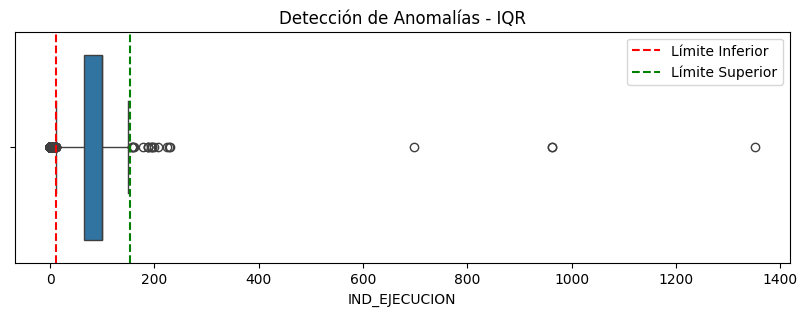

In [185]:
# =========================================================
# 32. VISUALIZACIÓN IQR
# =========================================================

plt.figure(figsize=(10,3))

sns.boxplot(
    x=df_t4['IND_EJECUCION']
)

plt.axvline(
    limite_inferior,
    color='red',
    linestyle='--',
    label='Límite Inferior'

)

plt.axvline(
    limite_superior,
    color='green',
    linestyle='--',
    label='Límite Superior'

)

plt.title('Detección de Anomalías - IQR')
plt.legend()
plt.show()


In [186]:
# =========================================================
# 33. ALERTA REVERSIÓN PRESUPUESTAL
# =========================================================
# En acumulados trimestrales no deberían existir
# disminuciones fuertes entre trimestres.
# =========================================================

alerta_reversion = df_t4[

    df_t4['VAR_EJECUCION'] < 0

]

print('\n================ ALERTAS REVERSIÓN ================')
print(alerta_reversion.shape)




================ ALERTAS REVERSIÓN ================
(4023, 23)


In [187]:
# =========================================================
# 34. RESUMEN ALERTAS
# =========================================================

resumen_alertas = pd.DataFrame({

    'TIPO_ALERTA': [
        'BAJA_EJECUCION',
        'ALTA_EJECUCION',
        'ANOMALIA_IQR',
        'REVERSION_PRESUPUESTAL'

    ],

    'TOTAL_REGISTROS': [

        alerta_baja.shape[0],
        alerta_alta.shape[0],
        anomalias_iqr.shape[0],
        alerta_reversion.shape[0]

    ]

})

print('\n================ RESUMEN ALERTAS ================')
print(resumen_alertas)


================ RESUMEN ALERTAS ================
              TIPO_ALERTA  TOTAL_REGISTROS
0          BAJA_EJECUCION             3588
1          ALTA_EJECUCION              119
2            ANOMALIA_IQR             2636
3  REVERSION_PRESUPUESTAL             4023


In [188]:
# =========================================================
# DATASET CONSOLIDADO DE ALERTAS T4
# =========================================================

dataset_alertas_t4 = pd.concat([
    alerta_baja,
    alerta_alta,
    anomalias_iqr,
    alerta_reversion
], ignore_index=True)

# Eliminar registros repetidos
dataset_alertas_t4 = dataset_alertas_t4.drop_duplicates()

print(f'Registros con alertas: {len(dataset_alertas_t4):,}')

Registros con alertas: 5,523


In [189]:
# =========================================================
# 35. DATASET OPERACIONAL
# =========================================================
# IMPORTANTE:
# El dataset operacional incluye T1-T4
# para analizar la trayectoria completa
# de ejecución presupuestal anual.
# =========================================================

df_operacional = df.copy()

print('\n================ DATASET OPERACIONAL ================')
print(df_operacional.shape)

# =========================================================
# VALIDACIÓN TRIMESTRES
# =========================================================

print('\n================ TRIMESTRES DISPONIBLES ================')
print(
    sorted(
        df_operacional['TRIMESTRE']
        .unique()
    )
)


================ DATASET OPERACIONAL ================
(99726, 18)

================ TRIMESTRES DISPONIBLES ================
[1, 2, 3, 4]


In [190]:
# =========================================================
# 36. PERCENTILES POR TRIMESTRE
# =========================================================
# Los límites estadísticos se calculan
# independientemente para cada trimestre.
# =========================================================

percentiles_trim = (
    df_operacional
    .groupby('TRIMESTRE')['IND_EJECUCION']
    .quantile([0.25, 0.50, 0.75, 0.95])
    .unstack()
    .reset_index()
)

percentiles_trim.columns = [
    'TRIMESTRE',
    'P25',
    'P50',
    'P75',
    'P95'
]

print('\n================ PERCENTILES POR TRIMESTRE ================')
print(percentiles_trim)



================ PERCENTILES POR TRIMESTRE ================
   TRIMESTRE    P25    P50     P75      P95
0          1   0.00   0.00    0.00   85.368
1          2   0.00   0.00   54.11  100.000
2          3   0.00  49.38   95.95  100.000
3          4  64.54  99.98  100.00  100.000


In [191]:
# =========================================================
# 37. ALERTA BAJA EJECUCIÓN
# =========================================================
# Instituciones con ejecución inferior
# al percentil 25 de su trimestre.
# =========================================================

alerta_baja_trim = pd.DataFrame()

for trimestre in [1,2,3,4]:
    p25 = (
        percentiles_trim[
            percentiles_trim['TRIMESTRE'] == trimestre
        ]['P25']
        .values[0]

    )

    temp = df_operacional[
        (df_operacional['TRIMESTRE'] == trimestre)
        &
        (df_operacional['IND_EJECUCION'] < p25)
    ]

    alerta_baja_trim = pd.concat(
        [alerta_baja_trim, temp]
    )

print('\n================ ALERTA BAJA EJECUCIÓN ================')
print(alerta_baja_trim.shape)



================ ALERTA BAJA EJECUCIÓN ================
(3589, 18)


In [192]:
# =========================================================
# 38. ALERTA ALTA EJECUCIÓN
# =========================================================
# Instituciones por encima del percentil 95
# de su trimestre.
# =========================================================

alerta_alta_trim = pd.DataFrame()

for trimestre in [1,2,3,4]:
    p95 = (
        percentiles_trim[
            percentiles_trim['TRIMESTRE'] == trimestre
        ]['P95']
        .values[0]
    )

    temp = df_operacional[
        (df_operacional['TRIMESTRE'] == trimestre)
        &
        (df_operacional['IND_EJECUCION'] > p95)
    ]

    alerta_alta_trim = pd.concat(
        [alerta_alta_trim, temp]
    )

print('\n================ ALERTA ALTA EJECUCIÓN ================')
print(alerta_alta_trim.shape)


================ ALERTA ALTA EJECUCIÓN ================
(948, 18)


In [193]:
# =========================================================
# 39. ALERTA REVERSIÓN PRESUPUESTAL
# =========================================================
# En datos acumulativos no deberían existir
# disminuciones entre trimestres.
# =========================================================

alerta_reversion_trim = df_operacional[
    df_operacional['VAR_EJECUCION'] < 0

]

print('\n================ ALERTA REVERSIÓN ================')
print(alerta_reversion_trim.shape)



================ ALERTA REVERSIÓN ================
(15537, 18)


In [194]:
# =========================================================
# 40. ALERTA ESTANCAMIENTO
# =========================================================
# Instituciones sin cambios entre trimestres.
# =========================================================

alerta_estancamiento = df_operacional[
    df_operacional['VAR_EJECUCION'] == 0
]

print('\n================ ALERTA ESTANCAMIENTO ================')
print(alerta_estancamiento.shape)


================ ALERTA ESTANCAMIENTO ================
(20366, 18)


In [195]:
# =========================================================
# 41. ALERTA ACELERACIÓN ABRUPTA
# =========================================================
# Detecta aumentos extremos de ejecución.
# =========================================================

p95_variacion = (
    df_operacional['VAR_EJECUCION']
    .quantile(0.95)

)

alerta_aceleracion = df_operacional[
    df_operacional['VAR_EJECUCION'] > p95_variacion

]

print('\n================ ALERTA ACELERACIÓN ================')
print(alerta_aceleracion.shape)
print(f'Percentil 95 VAR_EJECUCION: {p95_variacion:.2f}')


================ ALERTA ACELERACIÓN ================
(2618, 18)
Percentil 95 VAR_EJECUCION: 99.79


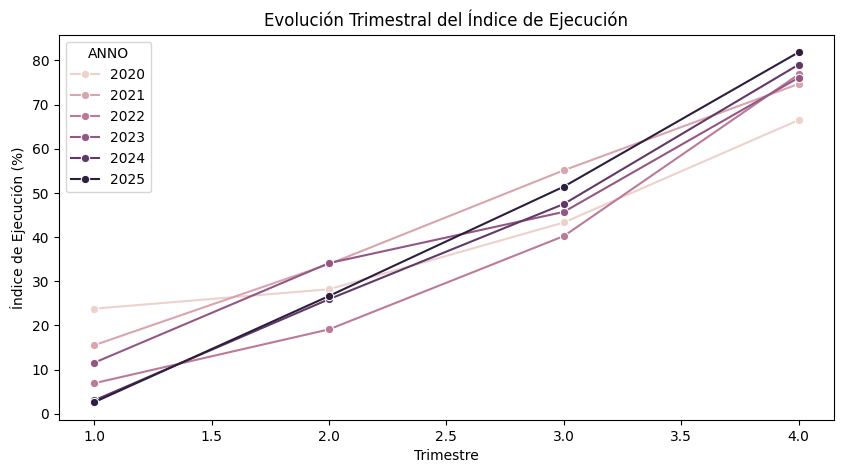

In [196]:
# =========================================================
# 42. EVOLUCIÓN TRIMESTRAL
# =========================================================

evolucion = (
    df_operacional
    .groupby(
        ['ANNO', 'TRIMESTRE']
    )['IND_EJECUCION']
    .mean()
    .reset_index()

)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=evolucion,
    x='TRIMESTRE',
    y='IND_EJECUCION',
    hue='ANNO',
    marker='o'

)

plt.title('Evolución Trimestral del Índice de Ejecución')
plt.ylabel('Índice de Ejecución (%)')
plt.xlabel('Trimestre')
plt.show()



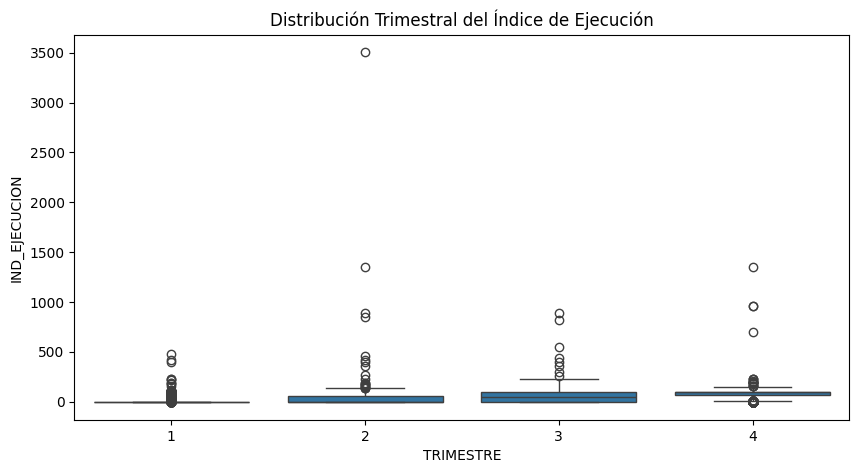

In [197]:
# =========================================================
# 43. DISTRIBUCIÓN POR TRIMESTRE
# =========================================================

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_operacional,
    x='TRIMESTRE',
    y='IND_EJECUCION'

)

plt.title('Distribución Trimestral del Índice de Ejecución')
plt.show()


In [198]:
# =========================================================
# 44. RESUMEN ALERTAS OPERACIONALES
# =========================================================

resumen_operacional = pd.DataFrame({

    'TIPO_ALERTA': [
        'BAJA_EJECUCION',
        'ALTA_EJECUCION',
        'REVERSION',
        'ESTANCAMIENTO',
        'ACELERACION'

    ],

    'TOTAL_REGISTROS': [
        alerta_baja_trim.shape[0],
        alerta_alta_trim.shape[0],
        alerta_reversion_trim.shape[0],
        alerta_estancamiento.shape[0],
        alerta_aceleracion.shape[0]
    ]

})

print('\n================ RESUMEN ALERTAS OPERACIONALES ================')
print(resumen_operacional)


================ RESUMEN ALERTAS OPERACIONALES ================
      TIPO_ALERTA  TOTAL_REGISTROS
0  BAJA_EJECUCION             3589
1  ALTA_EJECUCION              948
2       REVERSION            15537
3   ESTANCAMIENTO            20366
4     ACELERACION             2618


In [ ]:
# =========================================================
# 45. CONSOLIDACIÓN DE ALERTAS
# =========================================================
# Objetivo:
# Crear un único dataset de alertas para:
# - Dashboard BI
# - Visual Analytics
# - Seguimiento institucional
# - Clasificación de alertas
# =========================================================

print('\n================ CONSOLIDACIÓN ALERTAS ================')

# =========================================================
# ALERTA BAJA EJECUCIÓN
# =========================================================

alerta_baja_trim = alerta_baja_trim.copy()

alerta_baja_trim['TIPO_ALERTA'] = 'BAJA_EJECUCION'

# =========================================================
# ALERTA ALTA EJECUCIÓN
# =========================================================

alerta_alta_trim = alerta_alta_trim.copy()

alerta_alta_trim['TIPO_ALERTA'] = 'ALTA_EJECUCION'

# =========================================================
# ALERTA REVERSIÓN
# =========================================================

alerta_reversion_trim = alerta_reversion_trim.copy()

alerta_reversion_trim['TIPO_ALERTA'] = 'REVERSION'

# =========================================================
# ALERTA ESTANCAMIENTO
# =========================================================

alerta_estancamiento = alerta_estancamiento.copy()

alerta_estancamiento['TIPO_ALERTA'] = 'ESTANCAMIENTO'

# =========================================================
# ALERTA ACELERACIÓN
# =========================================================

alerta_aceleracion = alerta_aceleracion.copy()

alerta_aceleracion['TIPO_ALERTA'] = 'ACELERACION'

# =========================================================
# UNIFICAR ALERTAS
# =========================================================

dataset_alertas = pd.concat([
    alerta_baja_trim,
    alerta_alta_trim,
    alerta_reversion_trim,
    alerta_estancamiento,
    alerta_aceleracion

])

# =========================================================
# ELIMINAR DUPLICADOS
# =========================================================
# Una institución puede tener múltiples alertas.
# Eliminamos duplicados exactos.
# =========================================================

dataset_alertas = (
    dataset_alertas
    .drop_duplicates()

)

# =========================================================
# COLUMNAS PRINCIPALES
# =========================================================

columnas_alertas = [
    'ANNO',
    'TRIMESTRE',
    'DANE',
    'NOMBRE ESTABLECIMIENTO',
    'ITEM DETALLE',
    'TIPO',
    'TIPO_ALERTA',
    'PRESP_DEFINITIVO',
    'PAGOS',
    'RECAUDO',
    'IND_EJECUCION',
    'IND_COMPROMISO',
    'VAR_EJECUCION'

]

dataset_alertas = dataset_alertas[
    columnas_alertas
]

# =========================================================
# VALIDACIÓN ALERTAS
# =========================================================

print('\n================ DATASET ALERTAS ================')
print(dataset_alertas.shape)
print('\n================ TIPOS DE ALERTA ================')
print(
    dataset_alertas['TIPO_ALERTA']
    .value_counts()
)

# =========================================================
# RESUMEN ALERTAS
# =========================================================

resumen_alertas = (
    dataset_alertas
    .groupby('TIPO_ALERTA')
    .size()
    .reset_index(name='TOTAL')
)

print('\n================ RESUMEN ALERTAS ================')
print(resumen_alertas)


================ CONSOLIDACIÓN ALERTAS ================

================ DATASET ALERTAS ================
(43058, 12)

================ TIPOS DE ALERTA ================
TIPO_ALERTA
ESTANCAMIENTO     20366
REVERSION         15537
BAJA_EJECUCION     3589
ACELERACION        2618
ALTA_EJECUCION      948
Name: count, dtype: int64

================ RESUMEN ALERTAS ================
      TIPO_ALERTA  TOTAL
0     ACELERACION   2618
1  ALTA_EJECUCION    948
2  BAJA_EJECUCION   3589
3   ESTANCAMIENTO  20366
4       REVERSION  15537


In [200]:
# =========================================================
# 46. EXPORTAR DATASETS ANALÍTICOS
# =========================================================

df_operacional.to_csv(
    'dataset_operacional.csv',
    index=False
)

dataset_alertas.to_csv(
    'dataset_alertas.csv',
    index=False
)

df_t4.to_csv(
    'dataset_t4.csv',
    index=False
)

dataset_alertas_t4.to_csv(
    'dataset_alertas_t4.csv',
    index=False
)

print('\n================ EXPORTACIÓN FINALIZADA ================')
print('Archivos generados:')
print('- dataset_operacional.csv')
print('- dataset_t4.csv')
print('- dataset_alertas.csv')
print('- dataset_alertas_t4.csv')




================ EXPORTACIÓN FINALIZADA ================
Archivos generados:
- dataset_operacional.csv
- dataset_t4.csv
- dataset_alertas.csv
- dataset_alertas_t4.csv


In [201]:
# =======================================================
# Generación de archivos el .json para cargar en PowerBI
# =======================================================
df_t4.to_json(
    'dataset_t4.json',
    orient='records',
    force_ascii=False,
    indent=4
)

dataset_alertas_t4.to_json(
    'dataset_alertas_t4.json',
    orient='records',
    force_ascii=False,
    indent=4
)


dataset_alertas.to_json(
    'dataset_alertas.json',
    orient='records',
    force_ascii=False,
    indent=4
)

df_operacional.to_json(
    'df_operacional.json',
    orient='records',
    force_ascii=False,
    indent=4
)

In [202]:
# =======================================
# General Dataset para análisis con Excel
# =======================================

df_t4.to_excel('df_t4.xlsx', index=False)
df_operacional.to_excel('df_operacional.xlsx', index=False)
dataset_alertas.to_excel('dataset_alertas.xlsx', index=False)
dataset_alertas_t4.to_excel('dataset_alertas_t4.xlsx', index=False)